# 파노라마 객체 검출: 방법·변형 조건 비교 실험

SIFT, ORB, ALIKED의 검출 성공률과 실행 시간을 비교하고, 기준 물체의 회전·크기·조명 변화에 대한 강건성을 실험합니다.

In [ ]:
# ==========================================
# 라이브러리 및 프로젝트 모듈 Import
# ==========================================
import importlib
import logging
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

import src.experiment_runner as experiment_runner
importlib.reload(experiment_runner)

from src.logger import logger
from src.project_paths import (
    MATCHING_RESULT_DIR,
    OBJECT_DETECTION_RESULT_DIR,
    OBJECT_DIR,
    PANORAMA_IMAGE_DIR,
    PANORAMA_RESULT_DIR,
)
from src.settings import OBJECT_DETECTION_CONFIG
from src.experiment_runner import (
    discover_test_cases,
    read_image_for_display,
    run_batch,
    save_experiment_csv,
    summarize_records,
)

# ==========================================
# Notebook 출력 및 로그 설정
# ==========================================
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
cv2.utils.logging.setLogLevel(cv2.utils.logging.LOG_LEVEL_ERROR)

for handler in logger.handlers:
    if isinstance(handler, logging.StreamHandler) and not isinstance(handler, logging.FileHandler):
        handler.setLevel(logging.WARNING)

In [3]:
# ==========================================
# 탐색 파라미터 및 실험 조건 설정
# - main.py와 동일한 탐색 파라미터 사용
# - baseline만 결과·매칭 이미지를 저장
# - 변형 조건은 CSV와 비교표를 위한 지표만 저장
# ==========================================
TILE_SIZE = tuple(OBJECT_DETECTION_CONFIG['tile_size'])
COARSE_STRIDE = tuple(OBJECT_DETECTION_CONFIG['coarse_stride'])
FINE_STRIDE = tuple(OBJECT_DETECTION_CONFIG['fine_stride'])
COARSE_TOP_K = OBJECT_DETECTION_CONFIG['coarse_top_k']
EARLY_STOP_INLIERS = OBJECT_DETECTION_CONFIG['early_stop_inliers']

METHODS = tuple(OBJECT_DETECTION_CONFIG['methods'])
RESULT_ROOT = OBJECT_DETECTION_RESULT_DIR / 'batch'
MATCHING_ROOT = MATCHING_RESULT_DIR
METRICS_DIR = OBJECT_DETECTION_RESULT_DIR / 'metrics'

CONDITIONS = [
    {'name': 'baseline', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': True},
    {'name': 'rotation_minus30', 'rotation_deg': -30, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'rotation_plus30', 'rotation_deg': 30, 'scale_factor': 1.0, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'scale_075', 'rotation_deg': 0, 'scale_factor': 0.75, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'scale_125', 'rotation_deg': 0, 'scale_factor': 1.25, 'brightness_factor': 1.0, 'save_visuals': False},
    {'name': 'brightness_070', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 0.70, 'save_visuals': False},
    {'name': 'brightness_130', 'rotation_deg': 0, 'scale_factor': 1.0, 'brightness_factor': 1.30, 'save_visuals': False},
]

CONDITION_LABELS = {
    'baseline': '기본',
    'rotation_minus30': '회전 -30°',
    'rotation_plus30': '회전 +30°',
    'scale_075': '크기 75%',
    'scale_125': '크기 125%',
    'brightness_070': '조명 70%',
    'brightness_130': '조명 130%',
}


In [ ]:
# ==========================================
# 테스트 데이터 자동 탐색
# - targetN.jpg와 panoramaN.jpg를 번호 기준으로 연결
# ==========================================
TEST_CASES = discover_test_cases(
    target_dir=OBJECT_DIR,
    panorama_dir=PANORAMA_RESULT_DIR,
)

print('자동 탐색된 테스트 세트 수: ' + str(len(TEST_CASES)))
print('총 실험 횟수: ' + str(len(TEST_CASES) * len(METHODS) * len(CONDITIONS)))

FileNotFoundError: target*.jpg와 panorama*.jpg 쌍을 찾을 수 없습니다.

In [4]:
# ==========================================
# 전체 방법·변형 조건 일괄 실험
# - 정확도: 정답 쌍에서의 검출 성공률
# - 속도: 특징점 추출부터 Tile Scan까지의 전체 실행 시간
# ==========================================
batch_records = run_batch(
    test_cases=TEST_CASES,
    methods=METHODS,
    conditions=CONDITIONS,
    tile_size=TILE_SIZE,
    coarse_stride=COARSE_STRIDE,
    fine_stride=FINE_STRIDE,
    coarse_top_k=COARSE_TOP_K,
    early_stop_inliers=EARLY_STOP_INLIERS,
    result_root=RESULT_ROOT,
    matching_root=MATCHING_ROOT,
)

summary_rows = summarize_records(batch_records)
csv_paths = save_experiment_csv(
    records=batch_records,
    summary=summary_rows,
    output_dir=METRICS_DIR,
)

print('실험 완료: ' + str(len(batch_records)) + '회')
print('원본 기록 CSV: ' + csv_paths['records'])
print('요약 비교표 CSV: ' + csv_paths['summary'])

실험 완료: 42회
원본 기록 CSV: results\object_detection\metrics\experiment_records.csv
요약 비교표 CSV: results\object_detection\metrics\method_condition_summary.csv


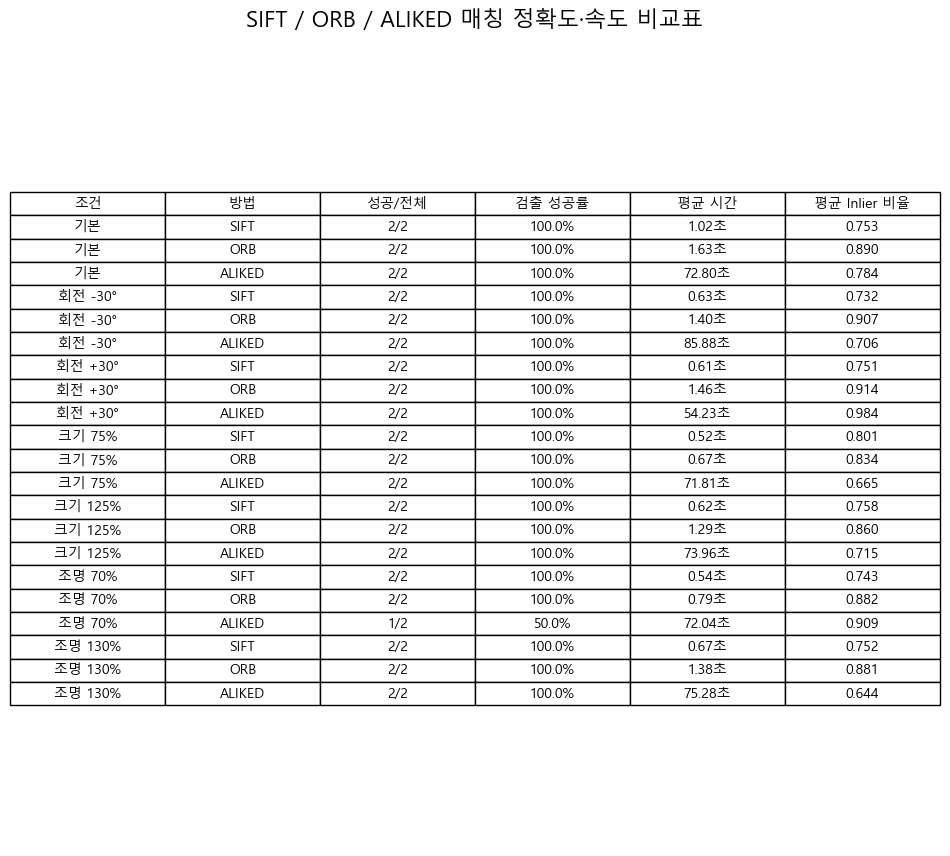

In [5]:
# ==========================================
# 방법별 매칭 정확도·속도 비교표 및 그래프
# - 정확도: Detection Success Rate
# - 속도: 평균 전체 실행 시간
# ==========================================
condition_names = [condition['name'] for condition in CONDITIONS]
summary_by_key = {(row['method'], row['condition']): row for row in summary_rows}

table_rows = []
for condition_name in condition_names:
    for method in METHODS:
        row = summary_by_key[(method, condition_name)]
        table_rows.append([
            CONDITION_LABELS[condition_name],
            method,
            str(row['detection_count']) + '/' + str(row['total_cases']),
            format(row['success_rate'] * 100, '.1f') + '%',
            format(row['mean_elapsed'], '.2f') + '초',
            format(row['mean_inlier_ratio'], '.3f'),
        ])

fig, axis = plt.subplots(figsize=(12, max(4, 0.42 * len(table_rows) + 1.5)))
axis.axis('off')
table = axis.table(
    cellText=table_rows,
    colLabels=['조건', '방법', '성공/전체', '검출 성공률', '평균 시간', '평균 Inlier 비율'],
    cellLoc='center',
    loc='center',
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
axis.set_title('SIFT / ORB / ALIKED 매칭 정확도·속도 비교표', fontsize=16, pad=18)
plt.show()



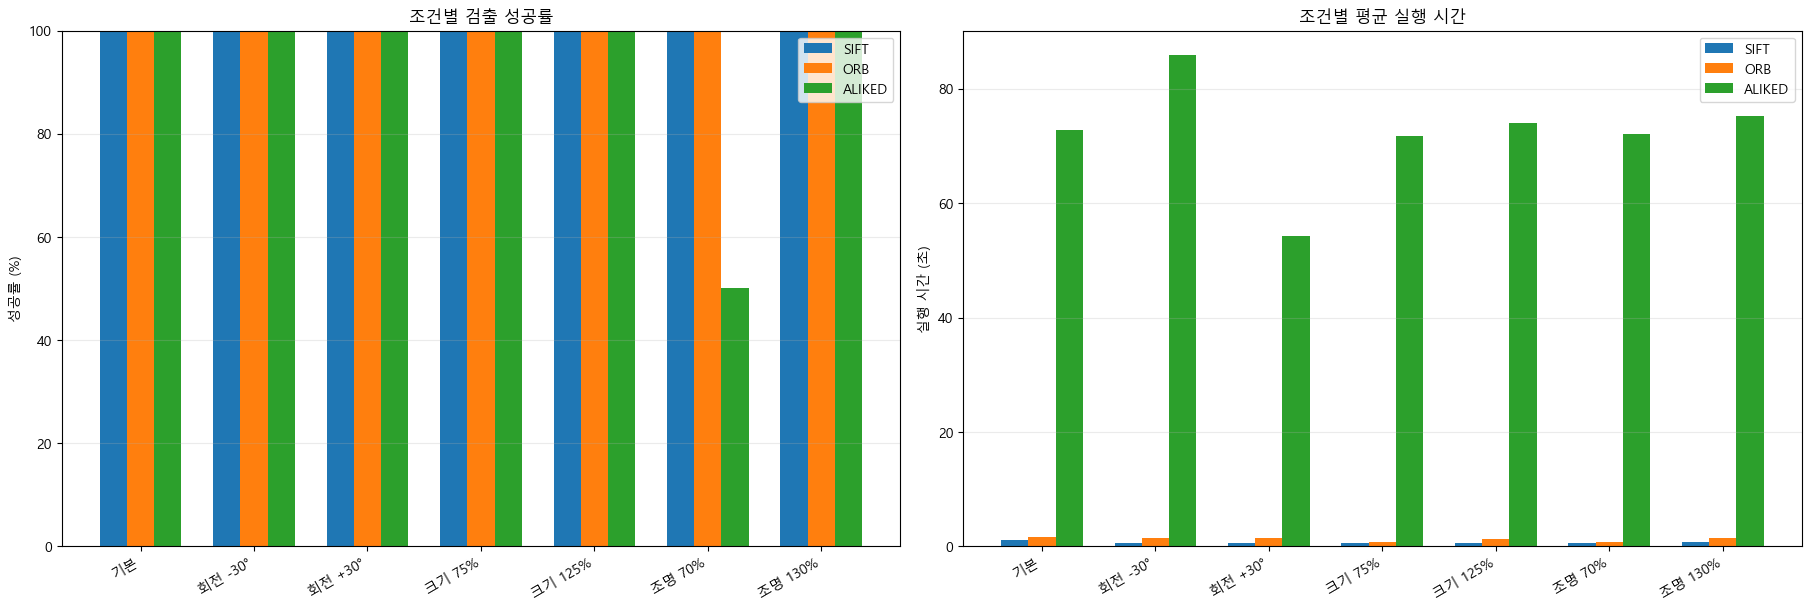

In [6]:
x_positions = np.arange(len(condition_names))
bar_width = 0.24
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

for index, method in enumerate(METHODS):
    success_rates = [summary_by_key[(method, name)]['success_rate'] * 100 for name in condition_names]
    elapsed_times = [summary_by_key[(method, name)]['mean_elapsed'] for name in condition_names]
    offset = (index - 1) * bar_width
    axes[0].bar(x_positions + offset, success_rates, bar_width, label=method)
    axes[1].bar(x_positions + offset, elapsed_times, bar_width, label=method)

labels = [CONDITION_LABELS[name] for name in condition_names]
axes[0].set_title('조건별 검출 성공률')
axes[0].set_ylabel('성공률 (%)')
axes[0].set_ylim(0, 100)
axes[1].set_title('조건별 평균 실행 시간')
axes[1].set_ylabel('실행 시간 (초)')

for axis in axes:
    axis.set_xticks(x_positions)
    axis.set_xticklabels(labels, rotation=30, ha='right')
    axis.legend()
    axis.grid(axis='y', alpha=0.25)

plt.show()

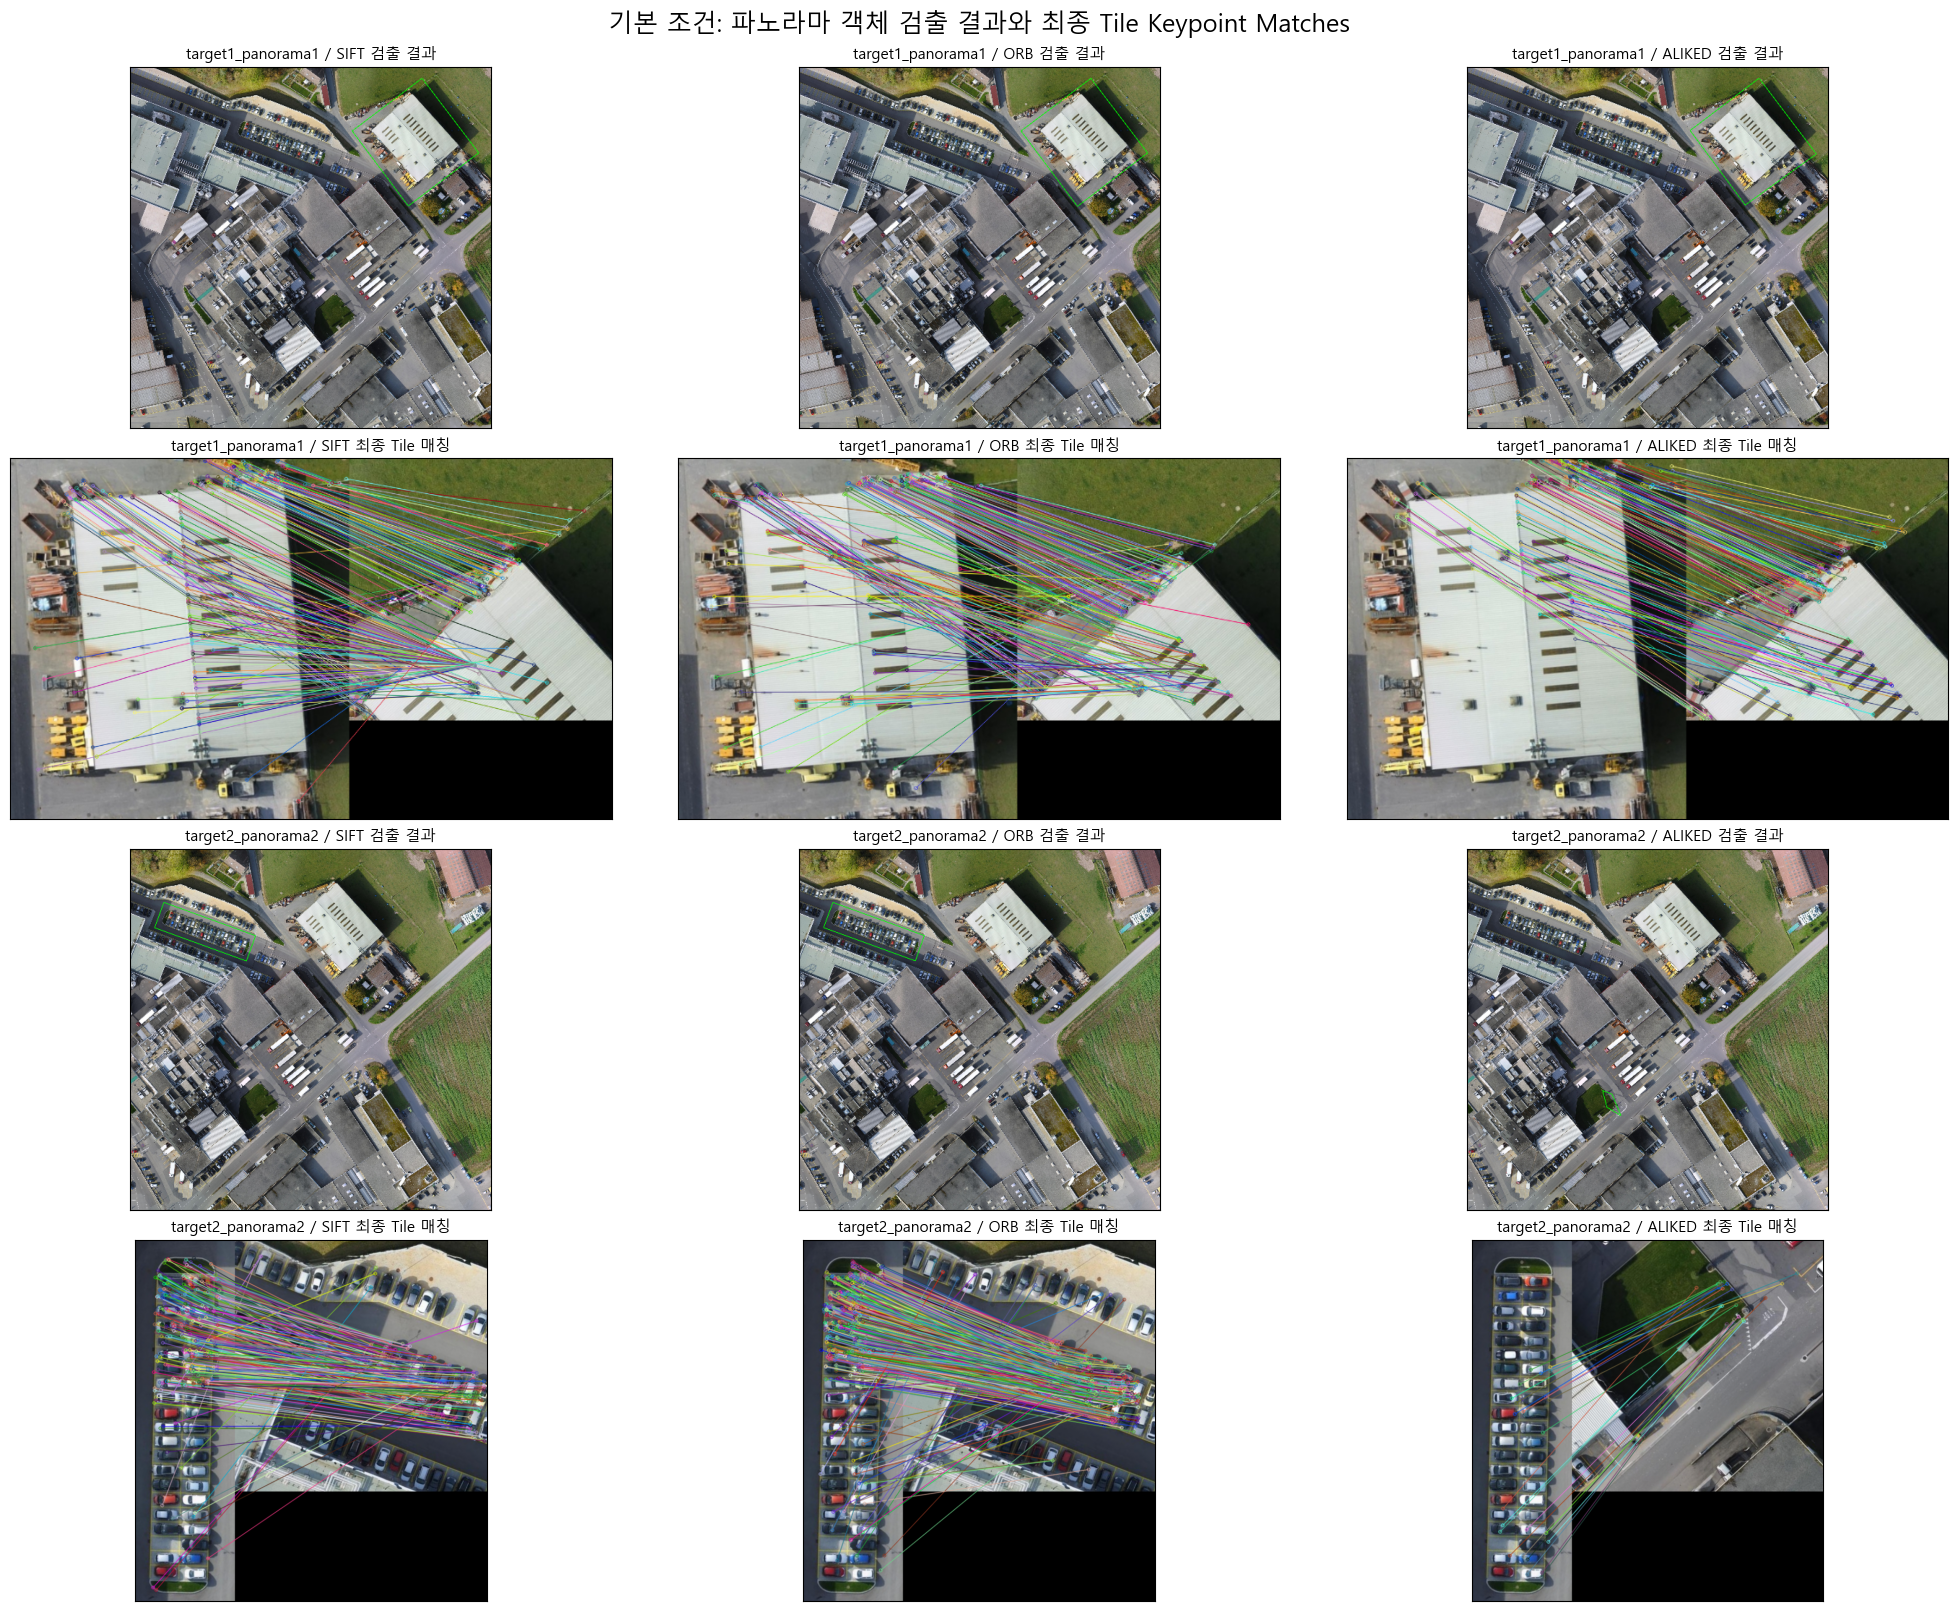

In [7]:
# ==========================================
# 기본 조건 검출 결과 및 최종 Tile 매칭 시각화
# - 위: Global Polygon이 표시된 최종 검출 결과
# - 아래: 같은 방법의 최종 Fine Tile Keypoint Matches
# ==========================================
VISUAL_CONDITION = 'baseline'

fig, axes = plt.subplots(
    2 * len(TEST_CASES),
    len(METHODS),
    figsize=(20, 8 * len(TEST_CASES)),
    constrained_layout=True,
)

for row, (case_name, _, _) in enumerate(TEST_CASES):
    for column, method in enumerate(METHODS):
        case_dir = RESULT_ROOT / case_name / VISUAL_CONDITION

        result_axis = axes[2 * row, column]
        result_axis.imshow(
            read_image_for_display(case_dir / (method + '_result.png'))
        )
        result_axis.set_title(case_name + ' / ' + method + ' 검출 결과', fontsize=11)

        match_axis = axes[2 * row + 1, column]
        match_path = case_dir / (method + '_keypoint_matches.png')
        if match_path.is_file():
            match_axis.imshow(read_image_for_display(match_path, max_width=700))
        else:
            match_axis.text(
                0.5, 0.5,
                '최종 Fine 후보 또는 매칭 이미지가 없습니다.',
                ha='center', va='center', wrap=True,
            )
        match_axis.set_title(case_name + ' / ' + method + ' 최종 Tile 매칭', fontsize=11)

        for axis in (result_axis, match_axis):
            axis.set_xticks([])
            axis.set_yticks([])

fig.suptitle('기본 조건: 파노라마 객체 검출 결과와 최종 Tile Keypoint Matches', fontsize=18)
plt.show()